# 05 · Feature Engineering

Build the model inputs and test whether the engineered features help. Tests use CV on the training split only. The transformers are in `src/seer_survival/features.py` and are fitted inside each fold.

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

from seer_survival import config as C
from seer_survival.data import load_clean
from seer_survival.features import FeatureEngineer, INPUT_COLS, make_preprocessor, make_column_transformer
from seer_survival.targets import make_surv
from seer_survival.training import make_split
from seer_survival.plots import set_style, save_fig, PALETTE

set_style()
df = load_clean()
split = make_split(df)
Xtr, ttr, etr = split["X_train"], split["t_train"], split["e_train"]
print(f"Training split: {len(Xtr)} patients, {etr.sum()} events | Test split held out: {len(split['X_test'])}")

Training split: 3219 patients, 493 events | Test split held out: 805


## 1. Inputs and outcomes

- **Inputs (12):** `age, race, marital_status, t_stage, n_stage, grade, a_stage, tumor_size, estrogen_status, progesterone_status, nodes_examined, nodes_positive`
- **Outcomes:** `survival_months, status, event`. These are never inputs.
- **Excluded:** `stage_6th`, since it is derived from T and N.

In [2]:
assert not set(C.LEAKAGE_COLS) & set(INPUT_COLS), "an outcome column is in the inputs!"
assert "stage_6th" not in INPUT_COLS
print("Leakage guard passed. Inputs:", INPUT_COLS)

Leakage guard passed. Inputs: ['age', 'race', 'marital_status', 't_stage', 'n_stage', 'grade', 'a_stage', 'tumor_size', 'estrogen_status', 'progesterone_status', 'nodes_examined', 'nodes_positive']


## 2. Engineered features

In [3]:
fe = FeatureEngineer().fit(Xtr)
eng = fe.transform(Xtr)
eng.head()

,age,log_tumor_size,nodes_examined,log_nodes_positive,node_ratio,t_stage,n_stage,grade,er_positive,pr_positive,distant_a_stage,race,marital_status,hr_status
0,54,3.135494,28,1.386294,0.107143,T2,N1,2,1,1,0,Other,Divorced,ER+/PR+
1,40,2.639057,21,0.693147,0.047619,T1,N1,2,1,1,0,White,Married,ER+/PR+
2,57,3.258097,16,2.564949,0.750000,T2,N3,3,1,0,0,White,Married,ER+/PR-
3,67,2.302585,24,1.945910,0.250000,T1,N2,2,1,1,0,White,Single,ER+/PR+
4,63,3.970292,27,1.386294,0.111111,T3,N1,2,1,1,0,White,Married,ER+/PR+


| Feature | Definition | Reason |
|---|---|---|
| `node_ratio` | positive ÷ examined nodes | prognostic in node-positive breast cancer (Vinh-Hung et al., 2009); strongest univariate signal here |
| `log_tumor_size`, `log_nodes_positive` | log(1 + x) | reduce skew for linear models |
| `hr_status` | joint ER/PR, 4 levels | the four combinations differ in risk |
| `er_positive`, `pr_positive`, `distant_a_stage` | 0/1 | binary recodes |
| `t_stage`, `n_stage`, `grade` | ordinal integers | keep clinical order |

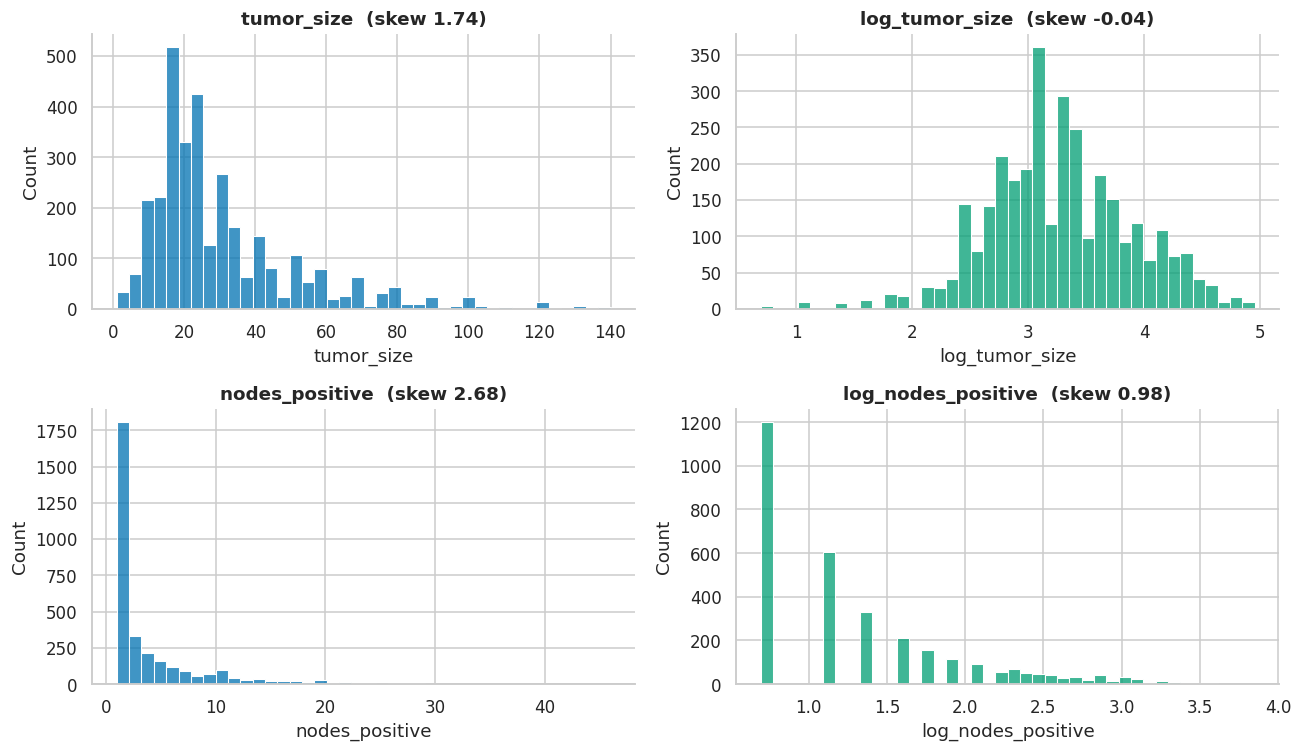

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (a, b) in zip(axes, [("tumor_size", "log_tumor_size"), ("nodes_positive", "log_nodes_positive")]):
    src = Xtr[a]; dst = eng[b]
    sns.histplot(src, bins=40, ax=ax[0], color=PALETTE[0]); ax[0].set_title(f"{a}  (skew {src.skew():.2f})")
    sns.histplot(dst, bins=40, ax=ax[1], color=PALETTE[2]); ax[1].set_title(f"{b}  (skew {dst.skew():.2f})")
fig.tight_layout(); save_fig(fig, "05_log_transforms"); plt.show()

## 3. Final encoded design matrix

In [5]:
prep = make_preprocessor(scale=True).fit(Xtr)
Xt = prep.transform(Xtr)
print("Encoded shape:", Xt.shape)
print("Columns:", list(Xt.columns))
Xt.describe().T[["mean", "std", "min", "max"]].round(2)

Encoded shape: (3219, 23)
Columns: ['age', 'log_tumor_size', 'nodes_examined', 'log_nodes_positive', 'node_ratio', 't_stage', 'n_stage', 'grade', 'er_positive', 'pr_positive', 'distant_a_stage', 'race_Black', 'race_Other', 'race_White', 'marital_status_Divorced', 'marital_status_Married', 'marital_status_Separated', 'marital_status_Single', 'marital_status_Widowed', 'hr_status_ER+/PR+', 'hr_status_ER+/PR-', 'hr_status_ER-/PR+', 'hr_status_ER-/PR-']


,mean,std,min,max
age,0.00,1.00,-2.67,1.69
log_tumor_size,0.00,1.00,-4.11,2.70
nodes_examined,0.00,1.00,-1.66,5.76
log_nodes_positive,-0.00,1.00,-0.92,3.55
node_ratio,0.00,1.00,-1.06,2.34
t_stage,0.00,1.00,-1.02,2.89
n_stage,-0.00,1.00,-0.63,2.23
grade,0.00,1.00,-1.81,2.88
er_positive,0.93,0.25,0.00,1.00
pr_positive,0.83,0.38,0.00,1.00


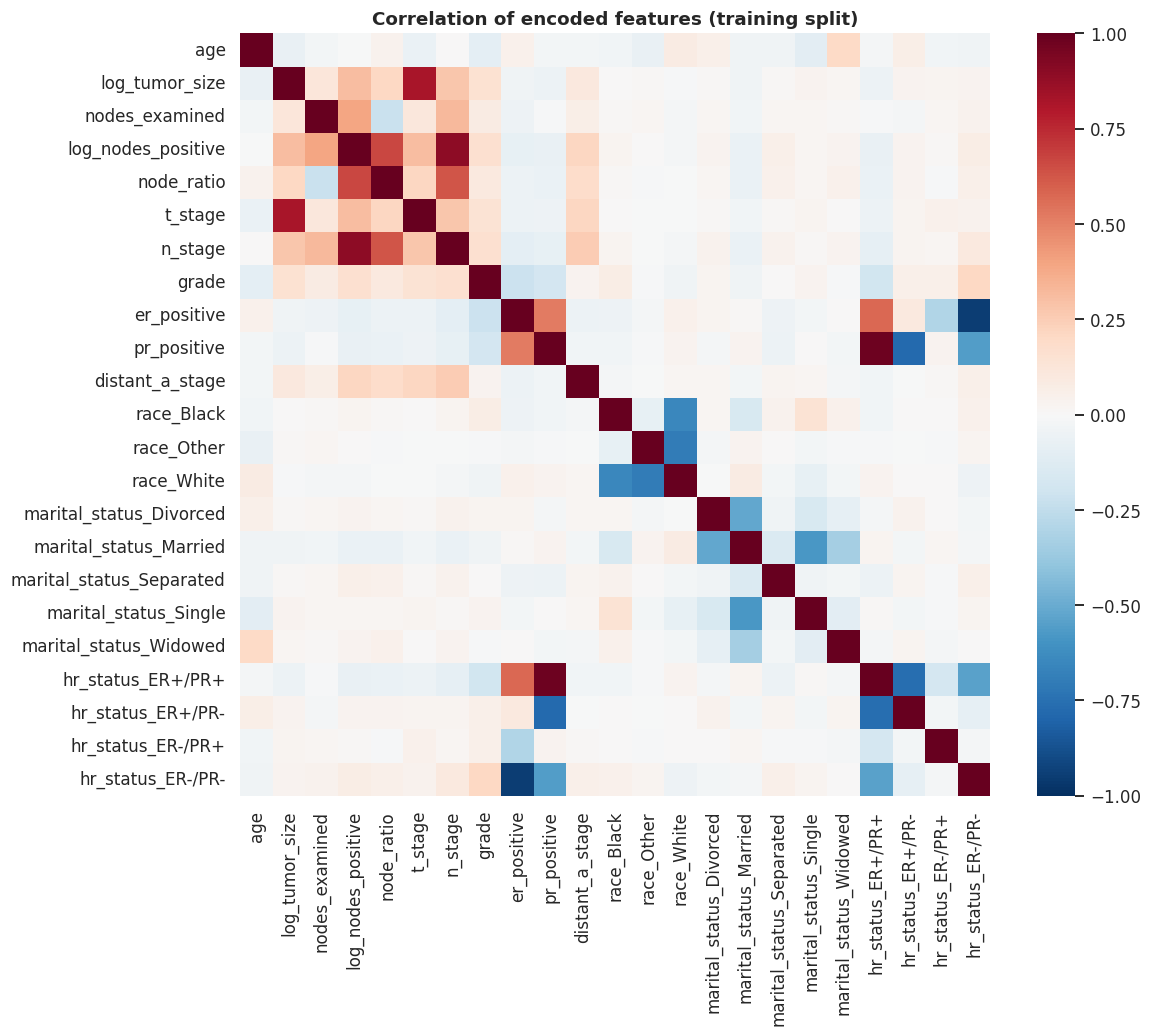

In [6]:
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(Xt.corr(), cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation of encoded features (training split)")
save_fig(fig, "05_encoded_corr"); plt.show()

One-hot columns of the same variable are negatively correlated by construction. That is harmless for regularised models. The remaining strong pairs (`n_stage`–`log_nodes_positive`, `t_stage`–`log_tumor_size`) are expected: the stage categories are built from these measurements.

## 4. Does `node_ratio` add information?

5-fold CV on the training split with a ridge Cox model (α = 0.1) and Harrell's C-index. Feature sets differ only in the tested feature, and the folds are the same for each.

In [7]:
class DropCols(BaseEstimator, TransformerMixin):
    def __init__(self, cols=()):
        self.cols = cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.drop(columns=list(self.cols))

class AddAgeSquared(BaseEstimator, TransformerMixin):
    """(standardised age)^2 - a simple U-shape term."""
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy(); X["age_sq"] = X["age"] ** 2
        return X

def cv_cindex(extra_steps, n_splits=5, seed=C.RANDOM_STATE):
    cv = StratifiedKFold(n_splits, shuffle=True, random_state=seed)
    scores = []
    for tr, va in cv.split(Xtr, etr):
        pipe = Pipeline([("prep", make_preprocessor(scale=True)), *extra_steps,
                         ("cox", CoxPHSurvivalAnalysis(alpha=0.1))])
        pipe.fit(Xtr.iloc[tr], make_surv(ttr[tr], etr[tr]))
        risk = pipe.predict(Xtr.iloc[va])
        scores.append(concordance_index_censored(etr[va].astype(bool), ttr[va], risk)[0])
    return np.array(scores)

variants = {
    "all engineered features (default)": [],
    "without node_ratio": [("drop", DropCols(["node_ratio"]))],
    "without node_ratio & nodes_examined": [("drop", DropCols(["node_ratio", "nodes_examined"]))],
    "default + age^2": [("age2", AddAgeSquared())],
}
res = {k: cv_cindex(v) for k, v in variants.items()}
tab = pd.DataFrame({k: v for k, v in res.items()}).T
tab.columns = [f"fold{i}" for i in range(tab.shape[1])]
tab["mean"] = tab.mean(axis=1); tab["sd"] = tab.iloc[:, :5].std(axis=1)
tab.round(4)

,fold0,fold1,fold2,fold3,fold4,mean,sd
all engineered features (default),0.7378,0.7211,0.7216,0.7588,0.7388,0.7356,0.0155
without node_ratio,0.7384,0.7234,0.7194,0.7580,0.7361,0.7350,0.0152
without node_ratio & nodes_examined,0.7301,0.7174,0.7196,0.7537,0.7268,0.7295,0.0145
default + age^2,0.7433,0.7316,0.7310,0.7552,0.7266,0.7375,0.0117


In [8]:
base = res["all engineered features (default)"]
rows = []
for k, v in res.items():
    if k == "all engineered features (default)":
        continue
    d = base - v
    rows.append({"comparison": f"default - [{k}]", "mean ΔC": d.mean(), "sd ΔC": d.std(ddof=1),
                 "folds where default better": int((d > 0).sum())})
pd.DataFrame(rows).round(4)

,comparison,mean ΔC,sd ΔC,folds where default better
0,default - [without node_ratio],0.0006,0.0020,3
1,default - [without node_ratio & nodes_examined],0.0061,0.0039,5
2,default - [default + age^2],-0.0019,0.0096,2


A positive ΔC favours the default set. With 5 folds this shows consistency, not significance; CV folds overlap, so paired t-tests would be too optimistic (Nadeau & Bengio, 2003).

## 5. Save processed features (for reference and external tools)

In [9]:
full = FeatureEngineer().fit(df[INPUT_COLS]).transform(df[INPUT_COLS])
full[C.TIME_COL] = df[C.TIME_COL].values
full[C.EVENT_COL] = df[C.EVENT_COL].values
full["split"] = "train"
full.loc[split["idx_test"], "split"] = "test"
C.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
full.to_csv(C.FEATURES_PATH, index=False)
print("saved", C.FEATURES_PATH.relative_to(ROOT), full.shape)
full["split"].value_counts()

saved data/processed/seer_features.csv (4024, 17)


split
train    3219
test      805
Name: count, dtype: int64

## Conclusions

| Test | Result | Decision |
|---|---|---|
| Node ratio, given both node counts | ΔC +0.0006, better in 3/5 folds | little added value; kept for interpretability |
| Node counts' denominator (examined nodes) | ΔC +0.0061, better in 5/5 folds | small but consistent value; kept |
| Age² term | ΔC +0.0019 for age², better in only 2/5 folds | not added |

Engineered features give small gains. Most of the signal is in the raw clinical variables.